In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re

In [2]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [3]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 73 directories


In [4]:
folder_info = ori_results

r1_bon_dummy_no_knowledge_l1 = []
o3_bon_dummy_no_knowledge_l1 = []
r1_aide_dummy_no_knowledge_l1 = []
o3_aide_dummy_no_knowledge_l1 = []

# print o3, bon, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: o3, bon, dummy, coder nok")
                    o3_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
# print r1, aide, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: r1, bon, dummy, coder nok")
                    r1_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: o3, aide, dummy, coder nok")
                    o3_aide_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: r1, aide, dummy, coder nok")
                    r1_aide_dummy_no_knowledge_l1.append(folder_name)

record_6_20250408_155217_1747668-1747662-5: o3, bon, dummy, coder nok
record_11_20250408_155217_1747662-1747662-10: o3, bon, dummy, coder nok
record_1_20250408_155217_1747663-1747662-0: o3, bon, dummy, coder nok
record_4_20250408_155217_1747666-1747662-3: o3, bon, dummy, coder nok
record_3_20250408_155217_1747665-1747662-2: o3, bon, dummy, coder nok
record_9_20250408_155217_1747671-1747662-8: o3, bon, dummy, coder nok
record_2_20250408_155217_1747664-1747662-1: o3, bon, dummy, coder nok
record_10_20250408_155217_1747672-1747662-9: o3, bon, dummy, coder nok
record_8_20250408_155217_1747670-1747662-7: o3, bon, dummy, coder nok
record_7_20250408_155217_1747669-1747662-6: o3, bon, dummy, coder nok
record_5_20250408_155217_1747667-1747662-4: o3, bon, dummy, coder nok
record_13_20250409_202152_1823339-1823335-2: o3, bon, dummy, coder nok
record_18_20250409_202152_1823335-1823335-7: o3, bon, dummy, coder nok
record_16_20250409_202152_1823342-1823335-5: o3, bon, dummy, coder nok
record_14_2025

In [5]:
r1_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l1}
o3_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l1}
r1_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l1}
o3_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_aide_dummy_no_knowledge_l1}

In [6]:

# o3_bon_dummy_no_knowledge_l1['record_3_20250408_155217_1747665-1747662-2']['metrics']
# for index, row in o3_bon_dummy_no_knowledge_l1['record_3_20250408_155217_1747665-1747662-2']['metrics'].iterrows():
#     print(f"Index: {index}, Row: {row.to_dict()}")

In [7]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [8]:
r1_bon_dummy_no_knowledge_l1 = process_metrics(r1_bon_dummy_no_knowledge_l1)
o3_bon_dummy_no_knowledge_l1 = process_metrics(o3_bon_dummy_no_knowledge_l1)
r1_aide_dummy_no_knowledge_l1 = process_metrics(r1_aide_dummy_no_knowledge_l1)
o3_aide_dummy_no_knowledge_l1 = process_metrics(o3_aide_dummy_no_knowledge_l1)

In [9]:
o3_bon_dummy_no_knowledge_l1['record_11_20250408_155217_1747662-1747662-10']
for index, row in o3_bon_dummy_no_knowledge_l1['record_11_20250408_155217_1747662-1747662-10']['metrics'].iterrows():
    print(f"Index: {index}, Row: {row.to_dict()}")

Index: 0, Row: {'step': 0.0, 'val_loss': 3.2742, 'train_time': 442985.0}
Index: 1, Row: {'step': 1.0, 'val_loss': nan, 'train_time': nan}
Index: 2, Row: {'step': 2.0, 'val_loss': 0.0063, 'train_time': 562309.0}
Index: 3, Row: {'step': 3.0, 'val_loss': 0.0063, 'train_time': 550625.0}
Index: 4, Row: {'step': 4.0, 'val_loss': 0.0063, 'train_time': 554588.0}
Index: 5, Row: {'step': 5.0, 'val_loss': 0.0063, 'train_time': 548617.0}
Index: 6, Row: {'step': 6.0, 'val_loss': 0.0062, 'train_time': 550541.0}
Index: 7, Row: {'step': 7.0, 'val_loss': 0.0062, 'train_time': 551656.0}
Index: 8, Row: {'step': 8.0, 'val_loss': 0.0063, 'train_time': 549270.0}
Index: 9, Row: {'step': 9.0, 'val_loss': 0.0063, 'train_time': 549350.0}
Index: 10, Row: {'step': 10.0, 'val_loss': 0.0062, 'train_time': 551545.0}
Index: 11, Row: {'step': 11.0, 'val_loss': 0.0063, 'train_time': 547558.0}
Index: 12, Row: {'step': 12.0, 'val_loss': nan, 'train_time': nan}
Index: 13, Row: {'step': 13.0, 'val_loss': 3.2774, 'train_tim

In [10]:
for k, v in r1_bon_dummy_no_knowledge_l1.items():
    metrics = v['metrics']
    print(f"Record: {k}, min train time idx: {metrics['train_time'].idxmin()}")

Record: record_1_20250408_155151_1747652-1747651-0, min train time idx: 94
Record: record_3_20250408_155151_1747654-1747651-2, min train time idx: 0
Record: record_8_20250408_155151_1747659-1747651-7, min train time idx: 0
Record: record_4_20250408_155151_1747655-1747651-3, min train time idx: 32
Record: record_6_20250408_155151_1747657-1747651-5, min train time idx: 105
Record: record_10_20250408_155151_1747661-1747651-9, min train time idx: 0
Record: record_2_20250408_155151_1747653-1747651-1, min train time idx: 57
Record: record_5_20250408_155151_1747656-1747651-4, min train time idx: 117
Record: record_7_20250408_155151_1747658-1747651-6, min train time idx: 45
Record: record_11_20250408_155151_1747651-1747651-10, min train time idx: 0
Record: record_9_20250408_155151_1747660-1747651-8, min train time idx: 58
Record: record_13_20250409_202141_1823330-1823327-2, min train time idx: 40
Record: record_16_20250409_202141_1823334-1823327-5, min train time idx: 55
Record: record_14_2025

In [11]:
for index, row in r1_bon_dummy_no_knowledge_l1['record_5_20250408_155151_1747656-1747651-4']['metrics'].iterrows():
    print(f"Index: {index}, Row: {row.to_dict()}")

Index: 0, Row: {'step': 0.0, 'val_loss': 3.2751, 'train_time': 949528.0}
Index: 1, Row: {'step': 1.0, 'val_loss': 16.0019, 'train_time': nan}
Index: 2, Row: {'step': 2.0, 'val_loss': nan, 'train_time': nan}
Index: 3, Row: {'step': 3.0, 'val_loss': nan, 'train_time': nan}
Index: 4, Row: {'step': 4.0, 'val_loss': 3.294, 'train_time': nan}
Index: 5, Row: {'step': 5.0, 'val_loss': 15.9845, 'train_time': nan}
Index: 6, Row: {'step': 6.0, 'val_loss': 15.9901, 'train_time': nan}
Index: 7, Row: {'step': 7.0, 'val_loss': 15.9832, 'train_time': nan}
Index: 8, Row: {'step': 8.0, 'val_loss': 15.9793, 'train_time': nan}
Index: 9, Row: {'step': 9.0, 'val_loss': 16.0172, 'train_time': nan}
Index: 10, Row: {'step': 10.0, 'val_loss': 15.9984, 'train_time': nan}
Index: 11, Row: {'step': 11.0, 'val_loss': 3.2748, 'train_time': 769504.0}
Index: 12, Row: {'step': 12.0, 'val_loss': 3.2758, 'train_time': 770425.0}
Index: 13, Row: {'step': 13.0, 'val_loss': 16.0384, 'train_time': nan}
Index: 14, Row: {'step':

In [12]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        results[record_num] = v['metrics']['train_time'].min()
    return results

r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

In [13]:
o3_bon_results

{6: 762428.0,
 11: 373.0,
 1: 2197667.0,
 4: 1290186.0,
 3: 61695.0,
 9: 505531.0,
 2: 1667018.0,
 10: 448137.0,
 8: 662205.0,
 7: 694203.0,
 5: 770095.0,
 13: 286045.0,
 18: 209785.0,
 16: 228874.0,
 14: 272870.0,
 17: 215166.0,
 12: 312671.0,
 15: 236979.0}

In [14]:
r1_bon_results

{1: 2350283.0,
 3: 1282839.0,
 8: 662205.0,
 4: 1288911.0,
 6: 766036.0,
 10: 477150.0,
 2: 1655817.0,
 5: 767046.0,
 7: 720216.0,
 11: 442985.0,
 9: 482356.0,
 13: 288704.0,
 16: 229421.0,
 14: 273107.0,
 12: 313128.0,
 15: 237214.0,
 18: 123456.0,
 17: 217349.0}

In [15]:

human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1282839,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [16]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [17]:
r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)


In [18]:
o3_bon_gap_in_percentage[3] = 0 # remove this because the summarizer somehow made a mistake here
o3_bon_gap_in_percentage[11] = 0 # remove this because the summarizer somehow made a mistake here

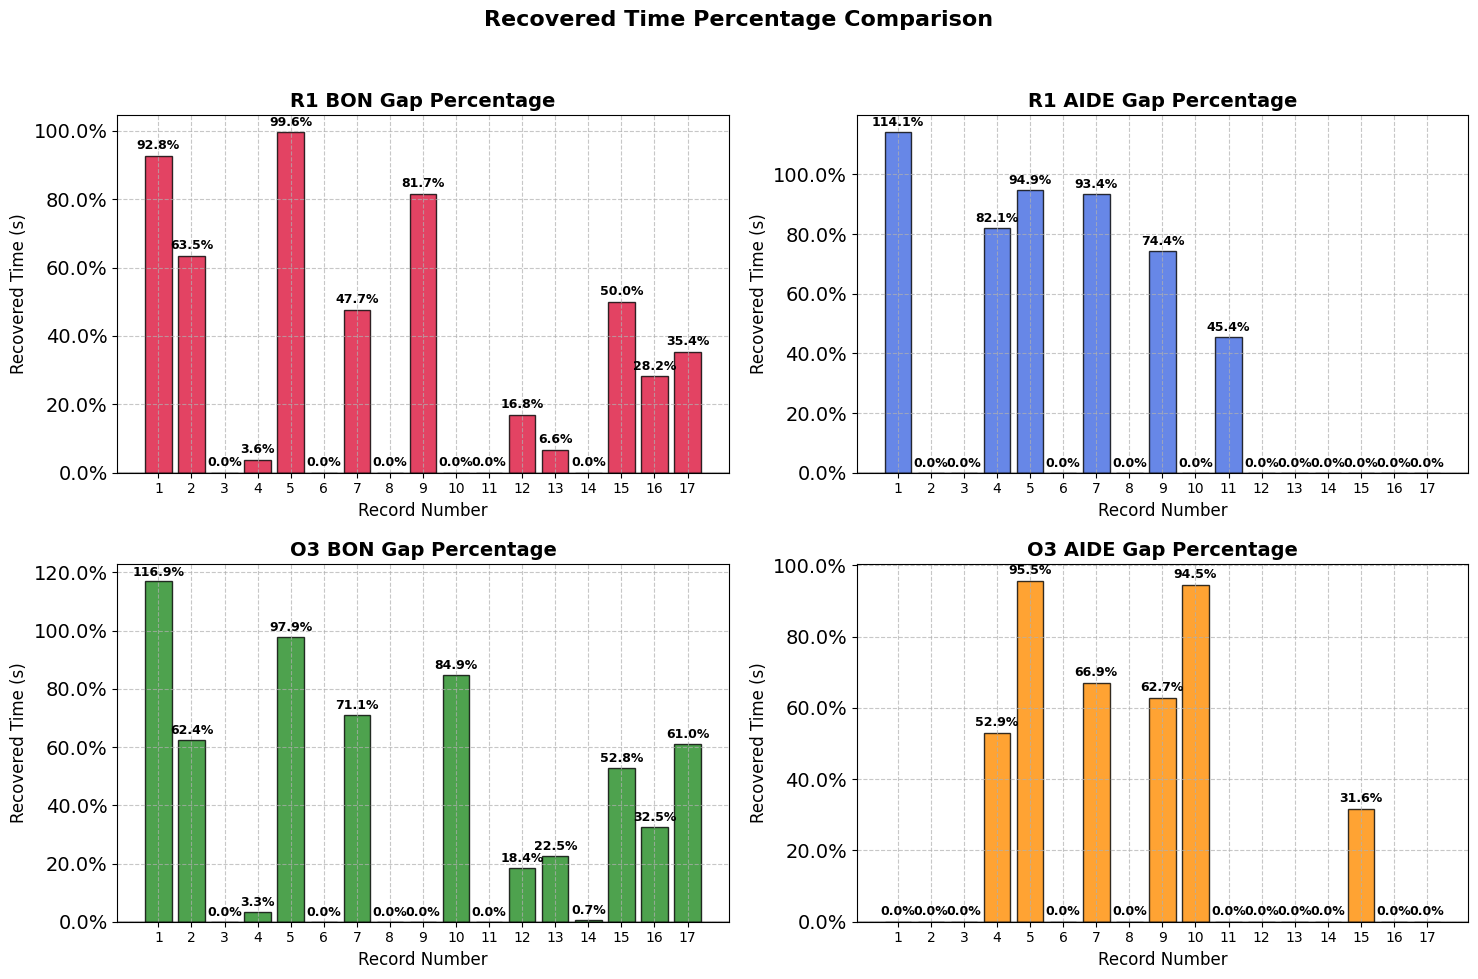

In [19]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
    (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
    (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
    (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items())
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(keys, values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(keys)
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()

In [20]:
o3_bon_results[11]

373.0

In [21]:
human_train_time_dict[11]

442985

In [30]:
r1_bon_results

{1: 2350283.0,
 3: 1282839.0,
 8: 662205.0,
 4: 1288911.0,
 6: 766036.0,
 10: 477150.0,
 2: 1655817.0,
 5: 767046.0,
 7: 720216.0,
 11: 442985.0,
 9: 482356.0,
 13: 288704.0,
 16: 229421.0,
 14: 273107.0,
 12: 313128.0,
 15: 237214.0,
 18: 123456.0,
 17: 217349.0}

In [22]:
human_train_time_dict[2]

2304681

In [23]:
o3_bon_results[1]

2197667.0

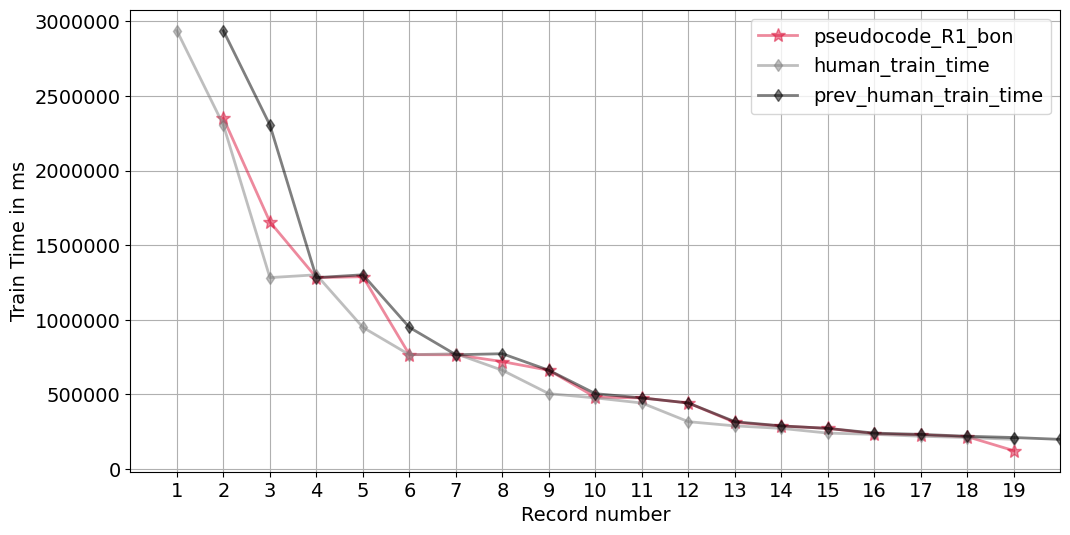

In [32]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


r1_bon_results_for_plot = {k + 1: v for k, v in sorted(r1_bon_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(r1_bon_results_for_plot.keys(), 
    r1_bon_results_for_plot.values(), 
    label='pseudocode_R1_bon', 
    color='crimson', linestyle='-', marker='*', markersize=10, linewidth=2, alpha=0.5)
ax.set_xlim(0, 20)
ax.set_xticks(range(1, 20))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 20}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

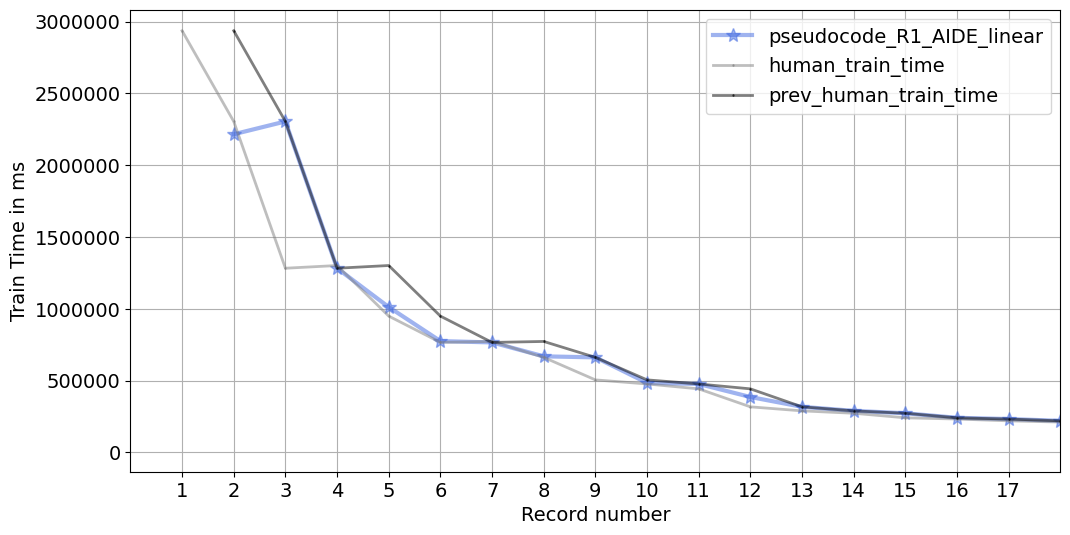

In [33]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


r1_aide_results_for_plot = {k + 1: v for k, v in sorted(r1_aide_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(r1_aide_results_for_plot.keys(), 
    r1_aide_results_for_plot.values(), 
    label='pseudocode_R1_AIDE_linear', 
    color='royalblue', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 18)
ax.set_xticks(range(1, 18))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 20}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

In [37]:
human_train_time_dict[11]

442985

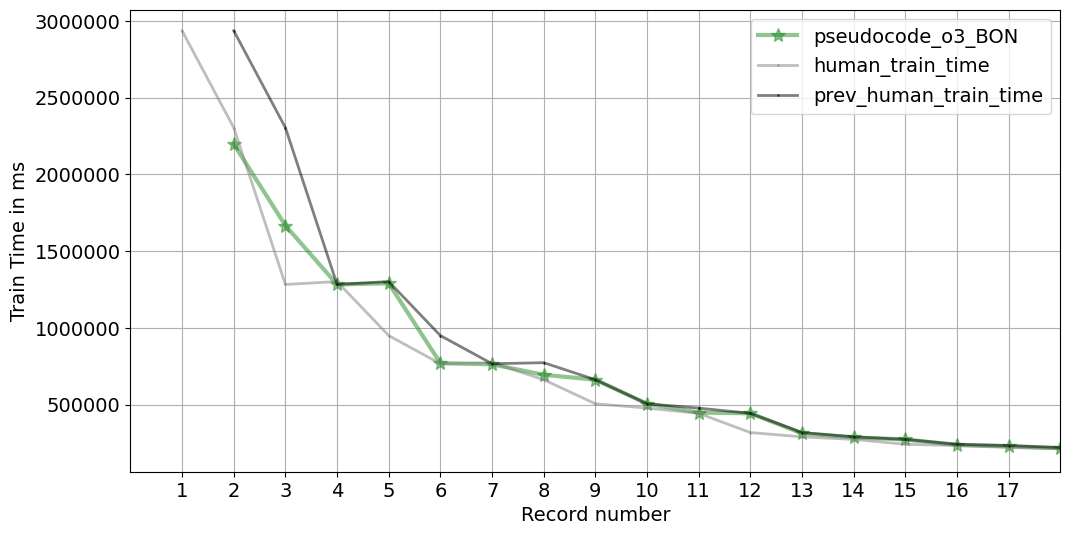

In [38]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_bon_results[3] = 1282839.0 #see note about problem with summarizer above
o3_bon_results[11] = 442985.0 #see note about problem with summarizer above
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


o3_bon_results_for_plot = {k + 1: v for k, v in sorted(o3_bon_results.items()) if k + 1 <= 19}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(o3_bon_results_for_plot.keys(), 
    o3_bon_results_for_plot.values(), 
    label='pseudocode_o3_BON', 
    color='forestgreen', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 18)
ax.set_xticks(range(1, 18))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 20}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

In [39]:
o3_bon_results

{6: 762428.0,
 11: 442985.0,
 1: 2197667.0,
 4: 1290186.0,
 3: 1282839.0,
 9: 505531.0,
 2: 1667018.0,
 10: 448137.0,
 8: 662205.0,
 7: 694203.0,
 5: 770095.0,
 13: 286045.0,
 18: 209785.0,
 16: 228874.0,
 14: 272870.0,
 17: 215166.0,
 12: 312671.0,
 15: 236979.0}

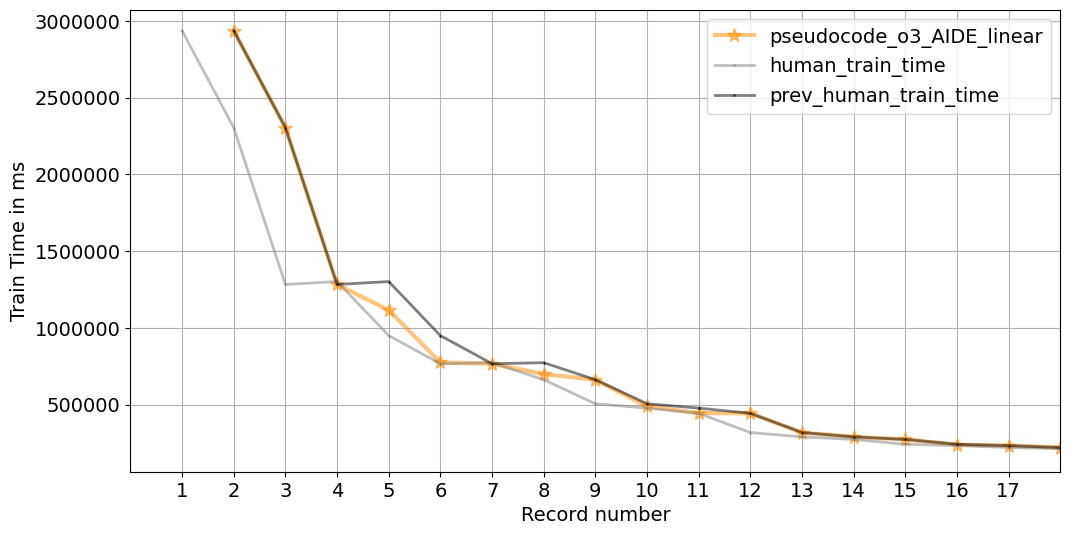

In [40]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


o3_aide_results_for_plot = {k + 1: v for k, v in sorted(o3_aide_results.items()) if k + 1 <= 19}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(o3_aide_results_for_plot.keys(), 
    o3_aide_results_for_plot.values(), 
    label='pseudocode_o3_AIDE_linear', 
    color='darkorange', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 18)
ax.set_xticks(range(1, 18))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 19}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 20}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()